# 🚀 Plotly Express — Interactive Data Visualization

**Topic:** 08.05 · **Level:** 🟠 Intermediate · **Type:** THEORY + CODE

## Why Plotly?

So far every chart you built — with Matplotlib and Seaborn — was a **static image**: rendered once, printed once, read once. Plotly is a different animal. It is a data-visualization library by the Canadian company Plotly Inc. that renders charts as **interactive vector graphics inside the browser or the notebook**. You get hover tooltips that show the exact data values, zoom and pan on any axis, click-to-highlight legends, 3D figures you can rotate by dragging, and even **animated** charts driven by a column of your data. Where Seaborn made figures prettier, Plotly makes them *alive*.

Plotly supports the same high-level ideas you already know — scatter, line, bar, histogram, pie, heatmap, 3D, subplots — but with a different mental model. It is language-agnostic (Python, R, JavaScript, Julia), which is why Plotly Express accepts almost identical syntax in multiple languages, and it produces standalone HTML, so a figure can be shared with anyone who opens a browser.

You will meet Plotly at three levels, the **Plotly roadmap**:

1. **Plotly Graph Objects (`go`)** — the low-level API. You build a chart by combining *traces* (`go.Scatter`, `go.Surface`, `go.Contour`...), a *layout* (`go.Layout` with title and axis titles) and a *figure* (`go.Figure(data, layout)`), then call `fig.show()`. Full control, more typing.
2. **Plotly Express (`px`)** — the high-level API. One function call per chart: `px.scatter(df, x=..., y=..., color=..., size=...)`. It is built on top of `go` and auto-correctly sets layout, legends and hover. 95% of your plotting will use `px`.
3. **Dash** — the web-application framework that turns Plotly figures into living dashboards with interactive controls. Outside the scope of this session, but the natural next step.

One honest caveat: Plotly is not designed for **live data streams**. For real-time feeds you would jump straight to Dash (or another streaming tool). This session focuses on Plotly Go and Plotly Express, powered by Plotly's built-in datasets (`px.data.tips()`, `px.data.iris()`, `px.data.gapminder()`).

## The Plotly Roadmap

Here is the mental map you should keep for the whole session — the three layers of the Plotly stack:

1. **Plotly Go (`plotly.graph_objects as go`)** — the foundational, low-level API. You think in *traces*: `go.Scatter(x=..., y=..., mode='markers')` creates one trace, several traces make the `data`, a `go.Layout(title=..., xaxis=..., yaxis=...)` drives the look, and `go.Figure(data, layout)` assembles the plot. Full pixel-level control, explicit and verbose.
2. **Plotly Express (`plotly.express as px`)** — the high-level, one-line API built *on top of* Go. `px.scatter(df, x=..., y=..., color=..., size=..., hover_name=...)` handles traces, layout and legend automatically and returns a ready figure. Prefer `px` everywhere unless you need Go's low-level machinery (surfaces, contours and subplot grids are Go's turf).
3. **Dash** — the application layer. Dash takes Express/Go figures and wires them into interactive multi-page web apps with dropdowns, sliders and live updates. Dash is out of scope for this notebook but it is the reason Plotly figures embed so naturally into browsers.

Rule of thumb for this session: start in Express (`px`), drop to Go when the chart type is not available in Express (surface, contour, raw circuit layout), and remember Dash exists for anything that must react to user input.

### Working with Plotly Go

## 📖 Plotly — interactive plotting

```python
import plotly.graph_objects as go   # low-level (Go)
import plotly.express as px         # high-level (Express)
```

- Plotly = **interactive** charts (hover, zoom)
- Express (`px`) — high-level, charts in a single line
- Go — low-level, trace-level control
- `px.data.tips()/iris()/gapminder()` — built-in datasets
- Roadmap: Go → Express → Dash (apps)


In [1]:
# import the libraries
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import plotly.express as px

In [2]:
!pip install plotly

In [3]:
# import datasets
tips = px.data.tips()
iris = px.data.iris()
gap = px.data.gapminder()

In [4]:
gap.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


## 📖 Scatter — go & px

```python
trace1 = go.Scatter(x=..., y=..., mode='markers', name=...)
px.scatter(gap, x='lifeExp', y='gdpPercap', color='continent',
           size='pop', hover_name='country',
           animation_frame='year')
```

- `go.Scatter` — trace object; join it in `.Figure(trace)`
- `mode='markers'|'lines'|'lines+markers'`
- `px.scatter` — color/size/hover in a single call
- `animation_frame` — automatic chart animation


## 🔬 Deep Dive : Plotly — interactive plots (go vs px)

```python
trace1 = go.Scatter(x=..., y=..., mode='markers', name=...)
layout = go.Layout(title='...', xaxis={'title':'...'}, yaxis={'title':'...'})
fig = go.Figure(data=[trace1, trace2], layout=layout)
fig.show()

# px = high-level (pref)
px.scatter(temp_df, x='lifeExp', y='gdpPercap', color='continent', size='pop', hover_name='country')
```

- Plotly = interactive, zoom, hover, pan web-format graphs
- **go** (graph_objects) low-level: trace + layout + figure
- **px** (express) high-level: one-liners with data semantics (color/size)
- plotly.express as px — preprocessor for go
- modes: markers/lines/markers+lines
- 3 levels: express → go → dash (apps)
- Hover shows point data values
- graphs embed HTML/Jupyter display
- hover_name — prominent tooltip label
- animation_frame — animate over a column (time!) — killer feature

In [5]:
# scatter plot using plotly go

temp_df = gap[gap['year'] == 2007]
temp_df

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
11,Afghanistan,Asia,2007,43.828,31889923,974.580338,AFG,4
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8
35,Algeria,Africa,2007,72.301,33333216,6223.367465,DZA,12
47,Angola,Africa,2007,42.731,12420476,4797.231267,AGO,24
59,Argentina,Americas,2007,75.320,40301927,12779.379640,ARG,32
...,...,...,...,...,...,...,...,...
1655,Vietnam,Asia,2007,74.249,85262356,2441.576404,VNM,704
1667,West Bank and Gaza,Asia,2007,73.422,4018332,3025.349798,PSE,275
1679,"Yemen, Rep.",Asia,2007,62.698,22211743,2280.769906,YEM,887
1691,Zambia,Africa,2007,42.384,11746035,1271.211593,ZMB,894


In [6]:

trace1 = go.Scatter(x=temp_df['lifeExp'],y=temp_df['gdpPercap'],mode='markers')
trace2 = go.Scatter(x=[0,1,2],y=[0,90,30000],mode='lines')

data = [trace1,trace2]

layout = go.Layout(title='Life Exp Vs GDP per Capita for 2007', xaxis={'title':'Life Exp'},yaxis={'title':'GDP'})
fig = go.Figure(data,layout)

fig.show()

In [7]:
# plot life exp and gdp scatter plot -> continent as color -> pop as size -> hover name -> range_x/range_y -> log_x/log_y
px.scatter(temp_df, x='lifeExp', y='gdpPercap',color='continent',size='pop',size_max=100, hover_name='country')

In [8]:
# plot animation of the above curve on the basic of year
px.scatter(gap, x='lifeExp', y='gdpPercap',
           color='continent',size='pop',
           size_max=100, hover_name='country',
           range_x=[30,95],
           animation_frame='year',animation_group='country')

## 📖 Line / Bar

```python
px.line(temp_df, x=..., y=...)   # time series
px.bar(temp_df, x=..., y=..., text_auto=True)  # annotations
px.bar(gap, x='continent', y='pop', color='continent',
       animation_frame='year')
```

- `px.line` — trends
- `text_auto=True` — value labels
- Stacked/grouped via `barmode`
- Animation bhi bar pe possible

## 🔬 Deep Dive : Line & Bar charts

```python
temp_df = gap[gap['country'] == 'India']
px.line(temp_df, x=temp_df.index, y=temp_df.columns)      # all cols vs index
px.bar(temp_df, x=temp_df.index, y=temp_df.columns)       # grouped
px.bar(temp_df, x=..., y=..., text_auto=True)             # values on tops
px.bar(gap, x='continent', y='pop', color='continent', animation_frame='year')
```

- line: time series for one main column (pop over years)
- multiple countries isin → multi lines compare (color auto)
- bar: aggregations; text_auto → annotate values
- grouped of multiple countries via cols selection
- stacked: parameter barmode='stack' or title stacking
- animation_frame 'year' — animate chart through time!
- Dash-ready interactive controls
- pop composition comparisons
- px.bar vertical default; orientation='h' horizontal
- color= encodes category identity

In [9]:
# line plot
# plot india pop line plot
temp_df = gap[gap['country'] == 'India']

px.line(temp_df, x='year', y='pop',title='India pop growth')

In [10]:
# plot india china pak line plot
temp_df = gap[gap['country'].isin(['India','China','Pakistan'])].pivot(index='year',columns='country',values='lifeExp')
temp_df

country,China,India,Pakistan
year,,,
1952,44.00000,37.373,43.436
1957,50.54896,40.249,45.557
1962,44.50136,43.605,47.670
1967,58.38112,47.193,49.800
1972,63.11888,50.651,51.929
1977,63.96736,54.208,54.043
1982,65.52500,56.596,56.158
1987,67.27400,58.553,58.245
1992,68.69000,60.223,60.838


In [11]:
px.line(temp_df, x=temp_df.index, y=temp_df.columns)

In [12]:
# bar chart
# india's pop over the years
temp_df = gap[gap['country'] == 'India']
px.bar(temp_df,x='year',y='pop')

In [13]:
# pop comp of 3 countries
temp_df = gap[gap['country'].isin(['India','China','Pakistan'])].pivot(index='year',columns='country',values='pop')
temp_df

country,China,India,Pakistan
year,,,
1952,556263527,372000000,41346560
1957,637408000,409000000,46679944
1962,665770000,454000000,53100671
1967,754550000,506000000,60641899
1972,862030000,567000000,69325921
1977,943455000,634000000,78152686
1982,1000281000,708000000,91462088
1987,1084035000,788000000,105186881
1992,1164970000,872000000,120065004


In [14]:
# grouped bar chart -> text_auto
px.bar(temp_df,x=temp_df.index,y=temp_df.columns,barmode='group',log_y=True,text_auto=True)

In [15]:
# stacked bar chart
# pop contribution per country to a continents pop stacked for a particular year(2007)
temp_df = gap[gap['year'] == 2007]
px.bar(temp_df, x='continent', y='pop', color='country',log_y=True)

In [16]:
# bar chart animation
px.bar(gap, x='continent',y='pop',color='continent',animation_frame='year',animation_group='country',range_y=[0,4000000000])

## 📖 Histogram / Pie / Sunburst / Treemap

```python
px.histogram(iris, x='sepal_length', nbins=20)
px.pie(values=..., names=..., hole=0.3)   # donut
px.sunburst(tips, path=['sex','smoker','day','time'], values='total_bill')
px.treemap(gap, path=[...], values='pop')
```

- `nbins` — histogram bins
- Pie `hole` → donut; `pull` → explode
- Sunburst/treemap — hierarchical data circular/box

### Histograms

A histogram answers "what does one numeric column look like?" — data goes into bins (intervals) and each bin becomes a bar whose height is the count. In Plotly Express: `px.histogram(df, x='col', nbins=N)`. The `nbins` argument controls granularity (10 bins for 2007 life expectancy keeps the shape clean; 30 bins for iris sepal length shows the multi-modal detail), and `text_auto=True` prints the counts on top of each bar. Adding `color='species'` separates the bars by category, showing you *three* overlaid histograms of the same variable. Histograms carry over the insight you got from seaborn's `displot`, but interactive: hover any bar to read its exact range and count.

In [17]:
# histogram
# plot histogram of life expt of all countries in 2007 -> nbins -> text_auto
temp_df = gap[gap['year'] == 2007]

px.histogram(temp_df, x='lifeExp',nbins=10,text_auto=True)

In [18]:
# plot histogram of sepal length of all iris species
px.histogram(iris,x='sepal_length',color='species',nbins=30,text_auto=True)

## 🔬 Deep Dive : Pie / Sunburst / Treemap

```python
px.pie(temp_df, values='pop', names='continent')          # share of total
px.pie(..., hole=0.3)                                     # donut explode
px.sunburst(tips, path=['sex','smoker','day','time'], values='total_bill', color='size')
px.treemap(temp_df, path=['continent','country'], values='pop', color='pop')
```

- pie — proportion categorical; values vs names pair
- donut: hole param — cleaner center label
- sunburst — hierarchical radial: levels → inner rings outward
- treemap — hierarchical rectangles: size= value, color= measure
- drill-down interactive (click collapse)
- plotly hierarchical charts built-in zoom
- path list = hierarchy chain columns
- values = numeric weight; color adds 2nd dimension
- world pop continent/nation breakdowns
- comparisons share-of-whole readability

In [19]:
# Pie -> values -> names
# find the pie chart of pop of european countries in 2007

temp_df = gap[(gap['year'] == 2007) & (gap['continent'] == 'Europe')]

px.pie(temp_df, values='pop', names='country')

In [20]:
# plot pie chart of world pop in 1952 continent wise ->  -> explode(pull)

temp_df = gap[gap['year'] == 1952].groupby('continent')['pop'].sum().reset_index()
px.pie(temp_df, values='pop', names='continent')

In [21]:
# Sunburst plot -> Sunburst plots visualize hierarchical data spanning outwards radially from root to leaves. -> color
# path -> [], values

temp_df = gap[gap['year'] == 2007]

px.sunburst(temp_df, path=['continent','country'],values='pop',color='lifeExp')

In [22]:
px.sunburst(tips,path=['sex','smoker','day','time'],values='total_bill',color='size')

In [23]:
# Treemap
temp_df = gap[gap['year'] == 2007]

px.treemap(temp_df, path=[px.Constant('World'),'continent','country'],values='pop',color='lifeExp')

## 📖 Heatmap / 3D / Matrix

```python
px.imshow(grid)                          # heatmap
px.scatter_3d(iris, x=..., y=..., z=..., color='species')
px.scatter_matrix(iris, dimensions=[...])  # pairplot
```

- Heatmap — pivot table matrix
- `scatter_3d` — 3 interactive dims
- `scatter_matrix` — pairwise scatter grid

## 🔬 Deep Dive : Heatmap / 3D / Scatter matrix

```python
px.imshow(grid)                     # numeric matrix as heatmap
px.scatter_3d(iris, x='sepal_length', y='sepal_width', z='petal_length', color='species')
px.scatter_matrix(iris, dimensions=['sepal_length','sepal_width','petal_length','petal_width'], color='species')
```

- imshow — 2D matrix color cells (pivot first)
- scatter_3d — xy z space colored by categorical — richness
- scatter_matrix — all pairs of dimensions — quick correlation eyeball
- dimensions list subset limits matrix view
- 3D interactive rotate in plotly
- hover info all dims
- color_group by species distinguishes classes
- Express covers all common chart families
- cluster/relationship viz for ML prep
- px has parallel_coordinates & dimension

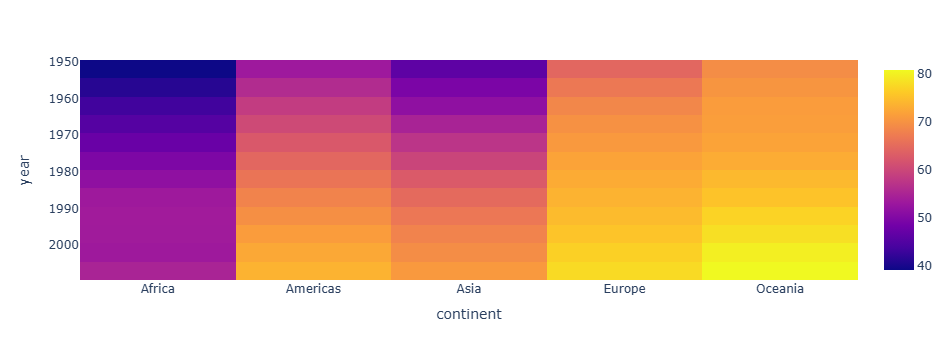

In [24]:
# Heatmap -> find heatmap of all continents with year on avg life exp
#temp_df = tips.pivot_table(index='day',columns='sex',values='total_bill',aggfunc='sum')

temp_df = gap.pivot_table(index='year',columns='continent',values='lifeExp',aggfunc='mean')
px.imshow(temp_df)

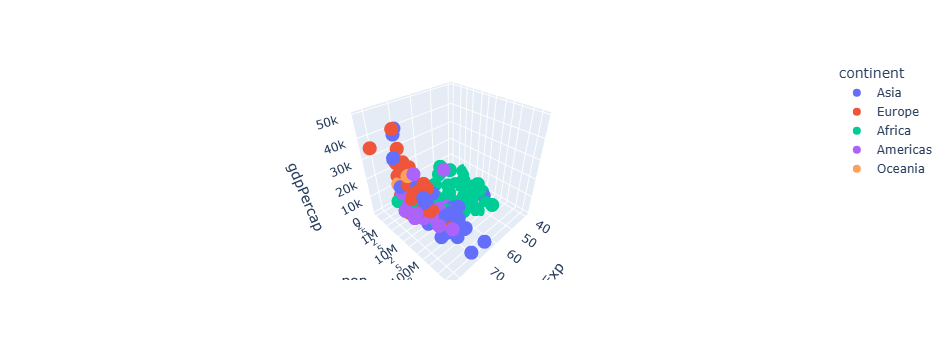

In [25]:
# 3d scatterplot
# plot a 3d scatter plot of all country data for 2007
temp_df = gap[gap['year'] == 2007]
px.scatter_3d(temp_df, x='lifeExp',y='pop',z='gdpPercap',log_y=True,color='continent',hover_name='country')

In [26]:
px.scatter_3d(iris,x='sepal_length',y='sepal_width',z='petal_length',color='species')

In [27]:
# scatter_matrix -> dimensions
px.scatter_matrix(iris,dimensions=['sepal_length','sepal_width','petal_length','petal_width'],color='species')

In [28]:
import plotly.graph_objects as go
import plotly.express as px
import numpy as np

## 📖 Faceting / Surface / Subplots

```python
px.scatter(tips, x='total_bill', y='tip',
           facet_col='smoker', facet_row='sex')
make_subplots(rows=2, cols=2)   # custom grids
fig.add_trace(go.Scatter(...), row=1, col=1)
```

- `facet_col/facet_row` — auto subplots
- `facet_col_wrap` — wrap columns
- Surface/contour via `go.Surface` / `go.Contour`
- `make_subplots` — manual layout control

## 🔬 Deep Dive : Faceting & subplots & surfaces

```python
px.scatter(tips, x='total_bill', y='tip', facet_col='smoker', facet_row='sex', color='sex')
px.scatter(gap, x='lifeExp', y='gdpPercap', facet_col='year', facet_col_wrap=3)

# surface/contour: plotly express NO — use go
xx,yy = np.meshgrid(x,y); z = xx**2 + yy**2
go.Figure(data=[go.Surface(x=xx, y=yy, z=z)])          # 3D surface
go.Contour(x=x, y=y, z=z)                              # contour

from plotly.subplots import make_subplots
fig = make_subplots(rows=2, cols=2)
fig.add_trace(go.Scatter(x=[1,9,5], y=[2,10,1]), row=1, col=1)
fig.show()
```

- facet_col/row — small multiples (grid panels by category)
- facet_col_wrap — wrap many facets rows
- surface/contour go-only — express gap typedef
- make_subplots + add_trace — different charts in grid
- go flexibility: any trace combination layout
- Canvas: 3D rotate, zoom hover everywhere
- Story: facet compare & combine dimensions
- px doesn't do surface; go step down when needed
- professional interactive reports end here

In [29]:
# facet plot
tips = px.data.tips()
gap = px.data.gapminder()

In [30]:
px.scatter(tips, x='total_bill', y='tip', facet_col='smoker', facet_row='sex',color='time')

In [31]:
px.histogram(tips,x='total_bill',facet_row='sex')

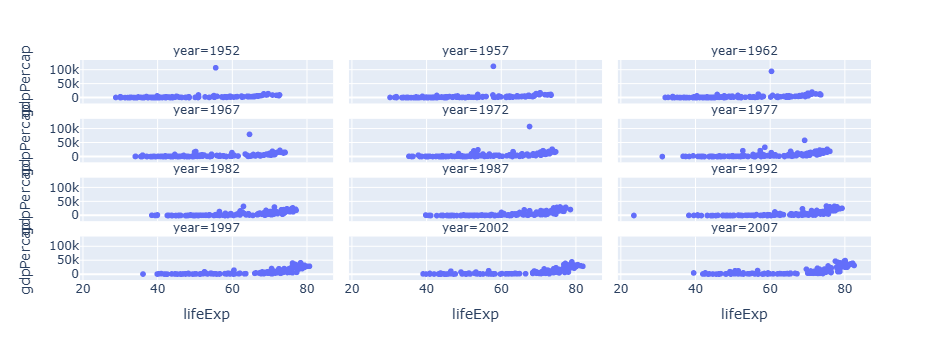

In [32]:
px.scatter(gap, x='lifeExp', y='gdpPercap', facet_col='year', facet_col_wrap=3)

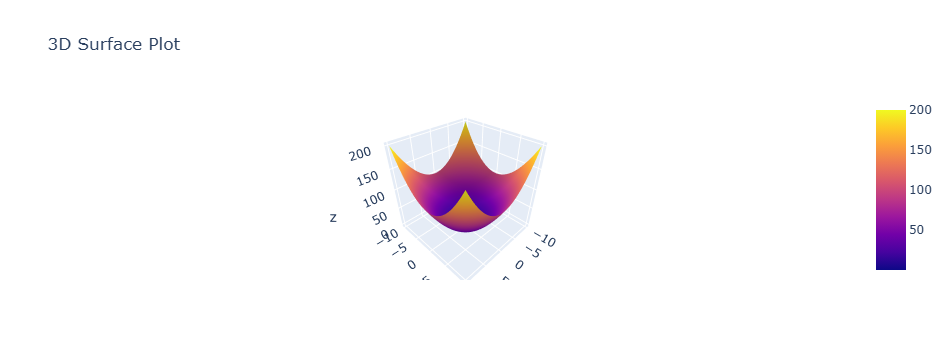

In [33]:
# 3d Surface plot
# can not be created using Plotly express
# we will use plotly graph object -> go

x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)

xx, yy = np.meshgrid(x,y)

z = xx**2 + yy**2
# z = np.sin(xx) + np.tan(yy)
# z = np.sqrt(xx**2 + yy**2)


trace = go.Surface(x=x,y=y,z=z)

data = [trace]

layout = go.Layout(title='3D Surface Plot')

fig = go.Figure(data,layout)

fig.show()

In [34]:
# Contour plot
x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)

xx, yy = np.meshgrid(x,y)

# z = xx**2 + yy**2
z = np.sin(xx) + np.cos(yy)
# z = np.sqrt(xx**2 + yy**2)


trace = go.Contour(x=x,y=y,z=z)

data = [trace]

layout = go.Layout(title='3D Surface Plot')

fig = go.Figure(data,layout)

fig.show()

In [35]:
# Subplots
from plotly.subplots import make_subplots

In [36]:
fig = make_subplots(rows=2,cols=2)

In [37]:
fig.add_trace(
    go.Scatter(x=[1,9,5],y=[2,10,1]),
    row = 1,
    col = 1
)

fig.add_trace(
    go.Histogram(x=[1,9,5,22,109,134,56,78,12,34,89]),
    row = 1,
    col = 2
)

fig.add_trace(
    px.Scatter(x=[1,9,5],y=[2,10,1]),
    row = 2,
    col = 1
)

fig.add_trace(
    go.Histogram(x=[1,9,5,22,109,134,56,78,12,34,89]),
    row = 2,
    col = 2
)

fig.update_layout(title='Subplot Demo')

fig.show()


AttributeError: module 'plotly.express' has no attribute 'Scatter'

## Summary

This session gave you the third major plotting framework: interactive charts via Plotly. You learned the roadmap — **Go** (low-level traces/layout/figure), **Express** (one-line `px` calls) and **Dash** (web apps) — and saw why Express is your default. You built the full Express catalogue on real data: scatters with `color`, `size`, `hover_name` and an animated `animation_frame`; line and bar charts (grouped, stacked, `text_auto` labels, animated continents); histograms with `nbins` and `color`; pie/donut, sunburst and treemap for hierarchical proportions; `imshow` heatmaps from pivots; 3D scatter via `px.scatter_3d` and `scatter_matrix` for pair slags. You then stepped down to Go for what Express cannot do — `go.Surface` and `go.Contour` built from `np.meshgrid(z)` — and assembled households subplots with `make_subplots` + `add_trace(row, col)`. Every figure was interactive: hover, zoom, rotate, animate. Plotly is the natural choice for exploratory shared dashboards; combined with Seaborn for stats-first charts, your visualization toolkit is complete.